In [49]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose

In [90]:
df=pd.read_csv(r"C:\Users\ganesh\Desktop\All Projects\Predicative care load Forecasting\data\raw\HHS_Unaccompanied_Alien_Children_Program.csv")

In [51]:
df.head()

,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
0,"December 21, 2025",6.0,18.0,11.0,"2,484",14.0
1,"December 18, 2025",11.0,50.0,6.0,"2,472",16.0
2,"December 17, 2025",7.0,31.0,11.0,"2,481",10.0
3,"December 16, 2025",8.0,54.0,15.0,"2,468",9.0
4,"December 15, 2025",11.0,42.0,9.0,"2,470",7.0


In [52]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1170 entries, 0 to 1169
Data columns (total 6 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   Date                                             720 non-null    str    
 1   Children apprehended and placed in CBP custody*  720 non-null    float64
 2   Children in CBP custody                          720 non-null    float64
 3   Children transferred out of CBP custody          720 non-null    float64
 4   Children in HHS Care                             720 non-null    str    
 5   Children discharged from HHS Care                720 non-null    float64
dtypes: float64(4), str(2)
memory usage: 69.5 KB


In [53]:
df.describe()

,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children discharged from HHS Care
count,720.000000,720.000000,720.000000,720.000000
mean,93.523611,171.494444,128.668056,173.406944
std,72.646625,126.354965,97.322012,125.702841
min,0.000000,7.000000,0.000000,0.000000
25%,12.000000,36.000000,14.000000,19.750000
50%,99.000000,193.000000,157.000000,181.000000
75%,147.250000,263.250000,199.250000,267.000000
max,333.000000,531.000000,440.000000,505.000000


In [54]:
df.shape

(1170, 6)

In [55]:
df["Date"]=pd.to_datetime(df["Date"])

In [56]:
df=df.sort_values("Date")

In [57]:
df.set_index("Date",inplace=True)

In [58]:
df.isnull().sum()

Children apprehended and placed in CBP custody*    450
Children in CBP custody                            450
Children transferred out of CBP custody            450
Children in HHS Care                               450
Children discharged from HHS Care                  450
dtype: int64

In [59]:
df.duplicated().sum()

np.int64(449)

In [60]:
df=df.dropna(how="all").copy()
df.shape

(720, 5)

In [61]:
df["Children in HHS Care"]=(
    df["Children in HHS Care"].astype(str).str.strip().str.replace(",","",regex=False)
)

In [62]:
df["Children in HHS Care"]= pd.to_numeric(df["Children in HHS Care"],errors="coerce")

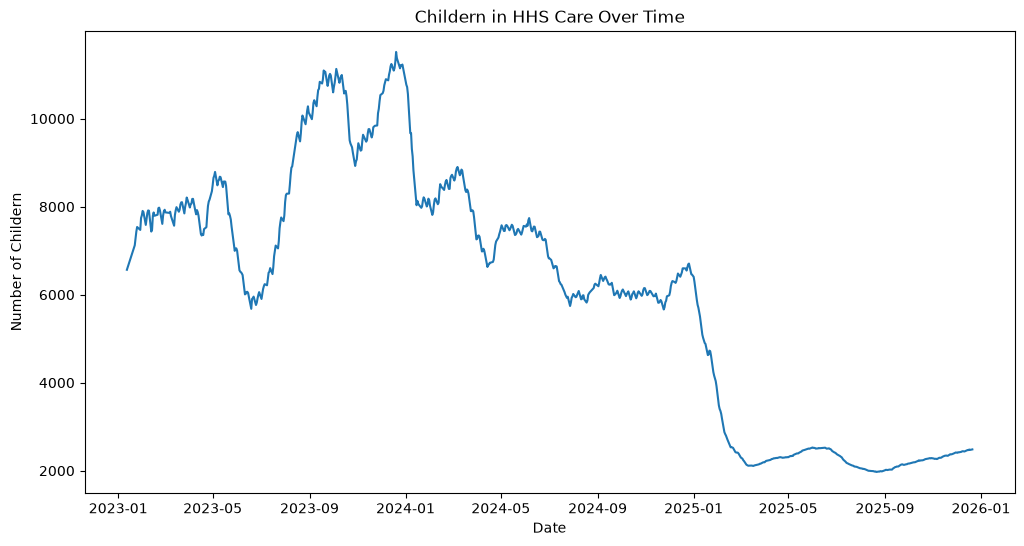

In [63]:
plt.figure(figsize=(12,6))
plt.plot(df["Children in HHS Care"])
plt.title("Childern in HHS Care Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Childern")
plt.show()

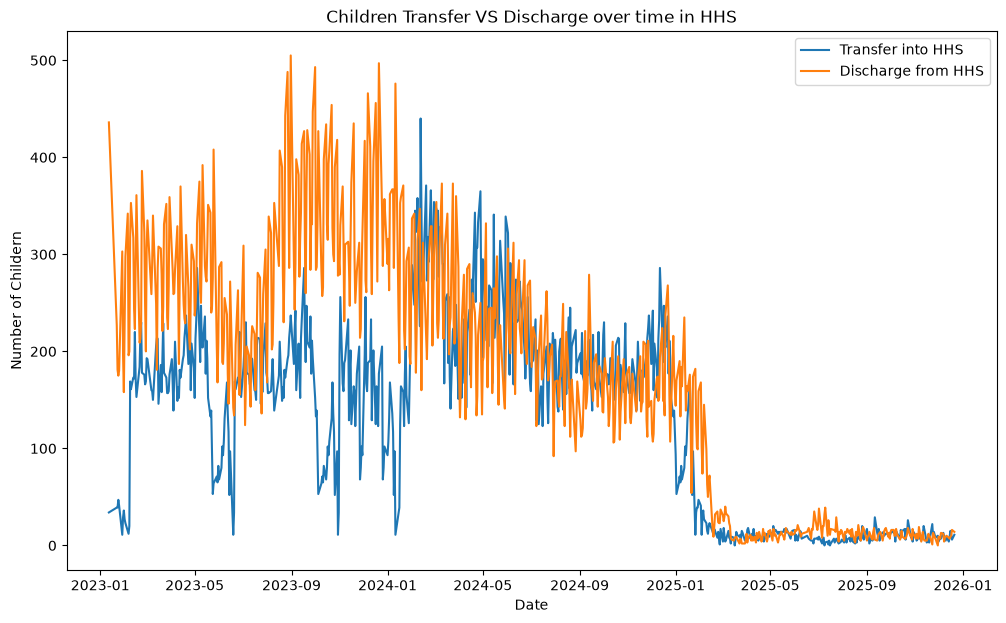

In [64]:
plt.figure(figsize=(12,7))
plt.plot(df["Children transferred out of CBP custody"],label="Transfer into HHS")
plt.plot(df["Children discharged from HHS Care"],label="Discharge from HHS")
plt.title("Children Transfer VS Discharge over time in HHS")
plt.xlabel("Date")
plt.ylabel("Number of Childern")
plt.legend()
plt.show()

In [65]:
numeric_column=df.select_dtypes(include=np.number).columns
numeric_column.tolist()

['Children apprehended and placed in CBP custody*',
 'Children in CBP custody',
 'Children transferred out of CBP custody',
 'Children in HHS Care',
 'Children discharged from HHS Care']

Histogram for every numeric column


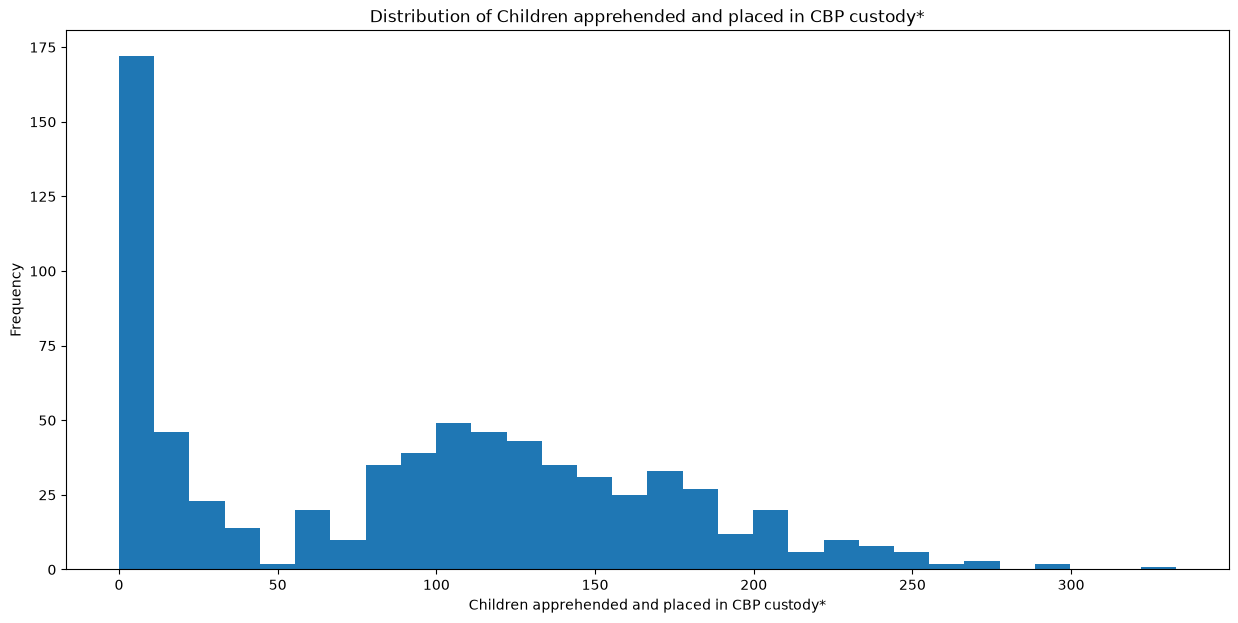

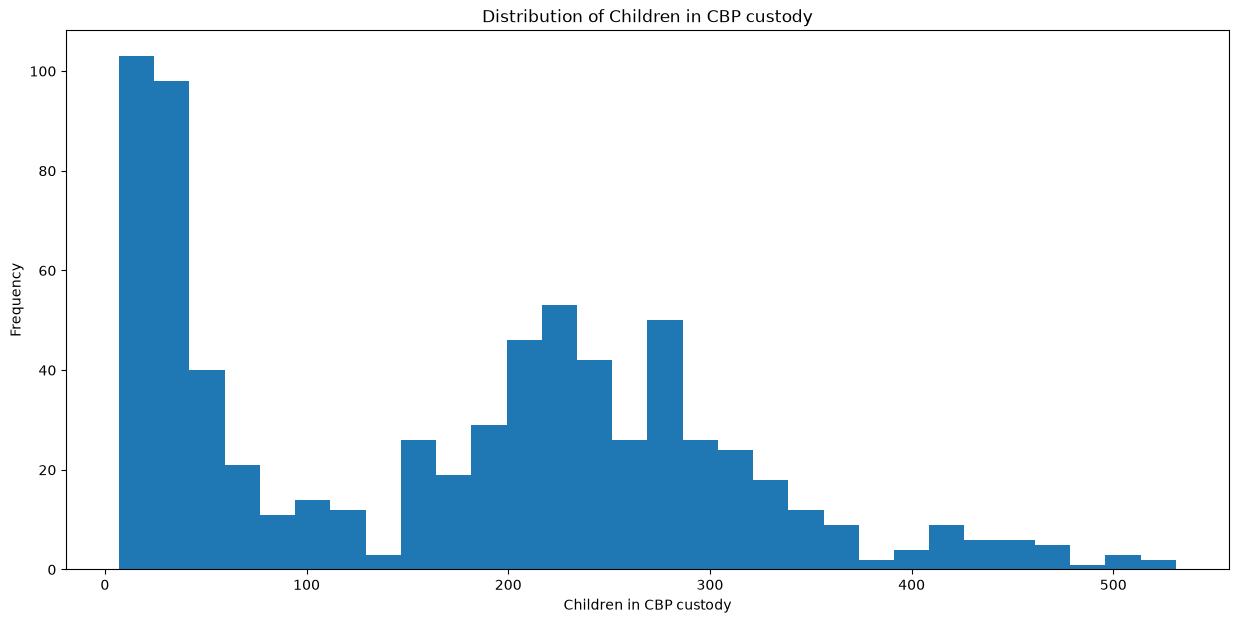

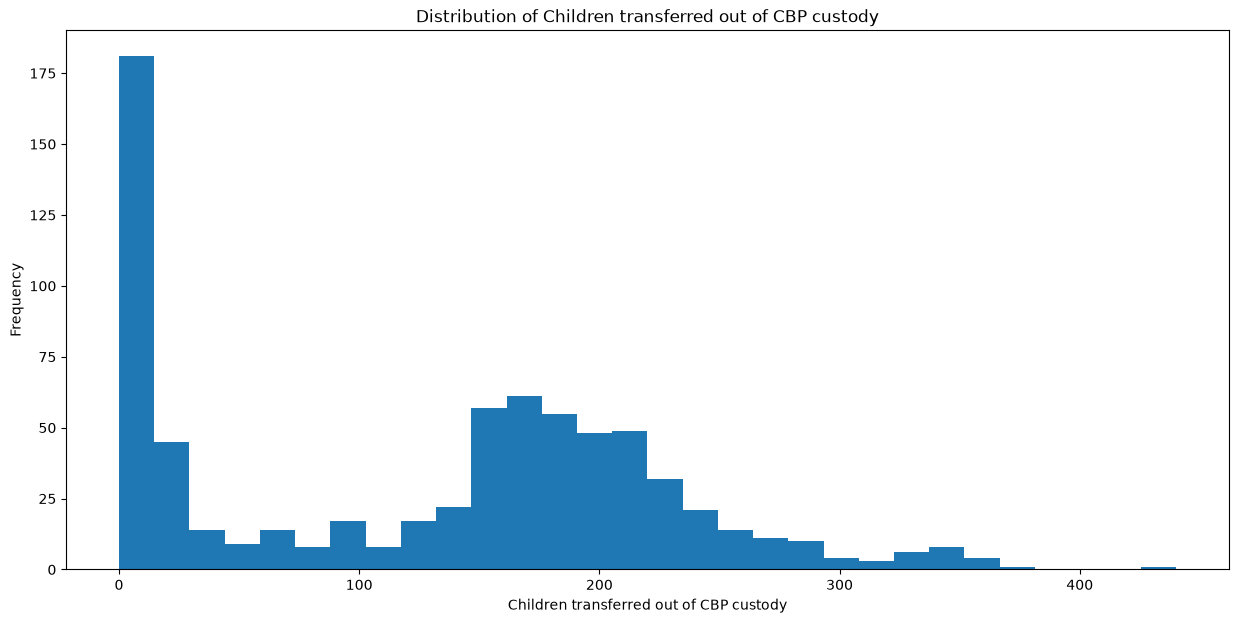

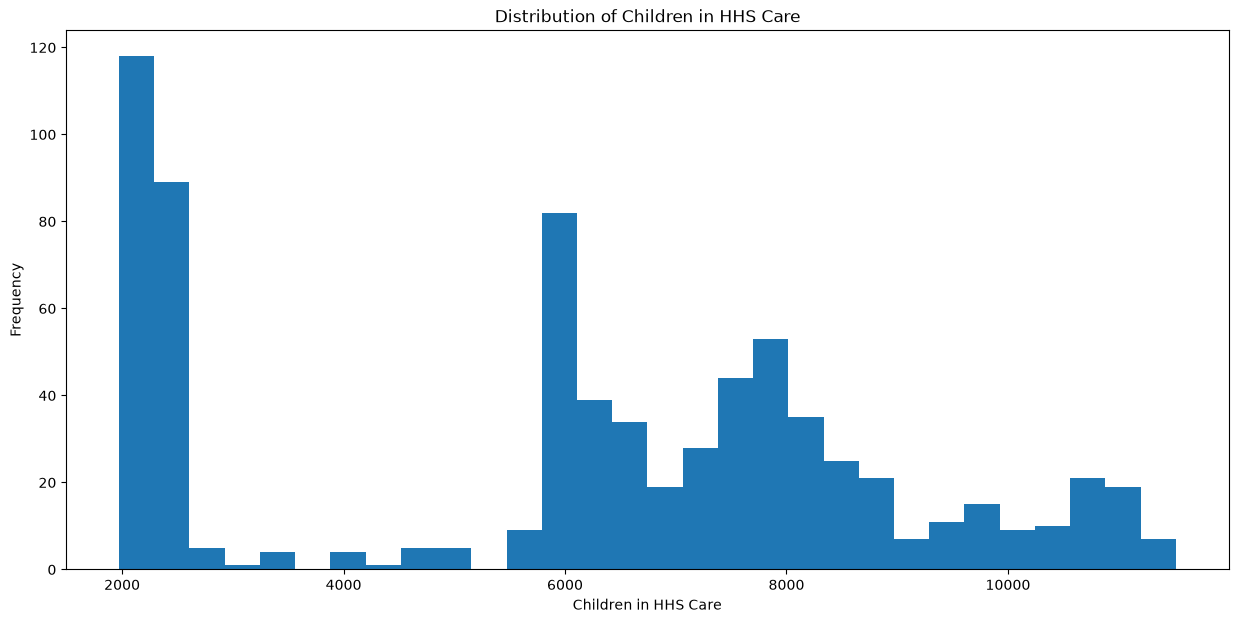

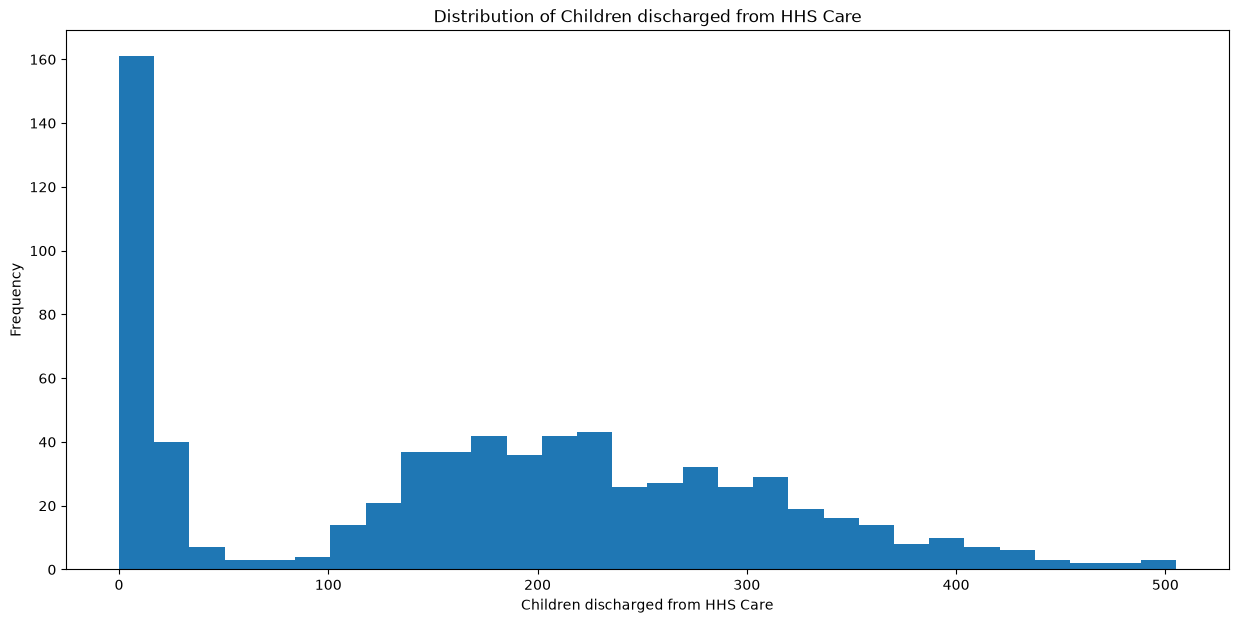

In [66]:
print("Histogram for every numeric column")
for column in numeric_column:
    plt.figure(figsize=(15,7))
    plt.hist(df[column].dropna(),bins=30)
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.show()

Boxplot for Outlier detection 


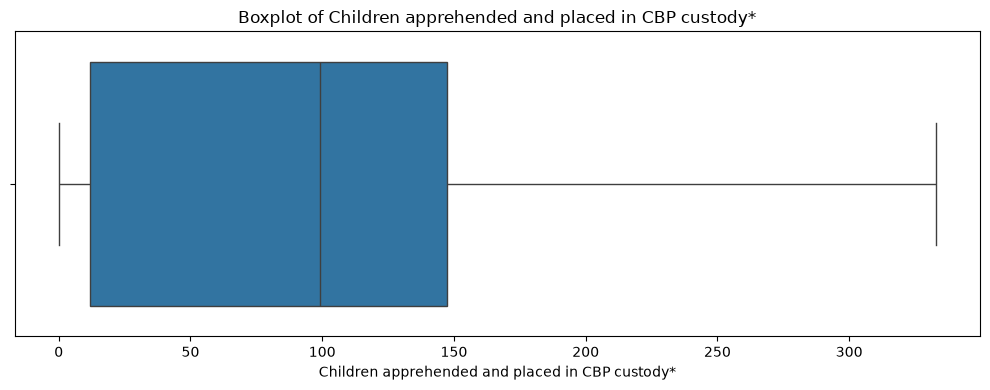

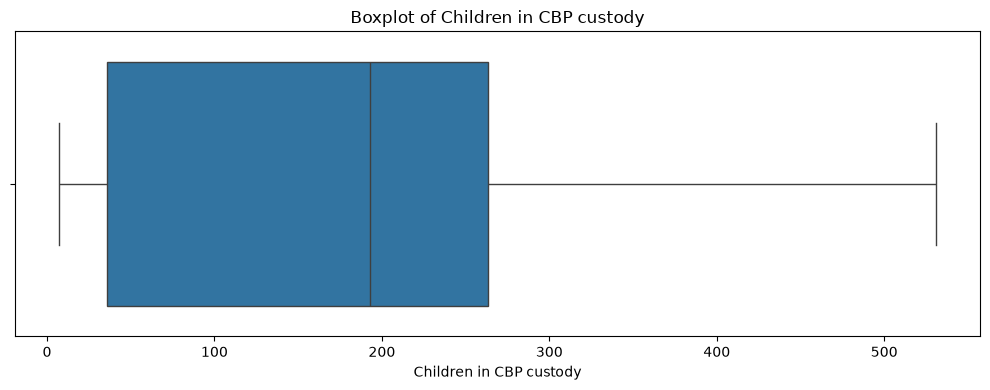

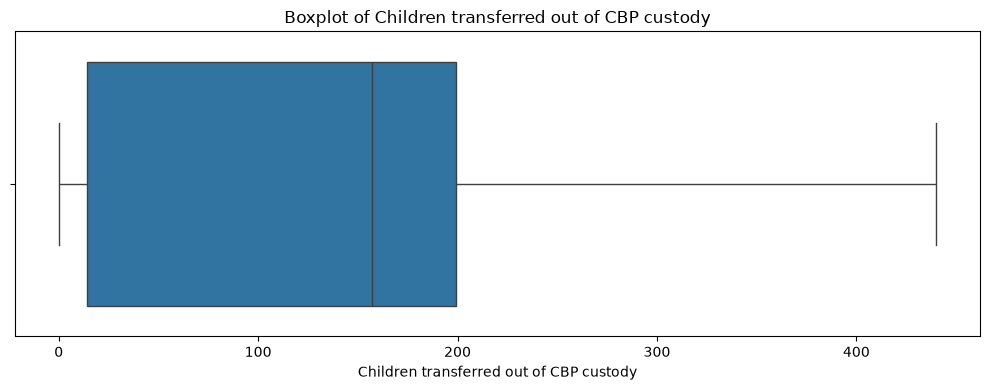

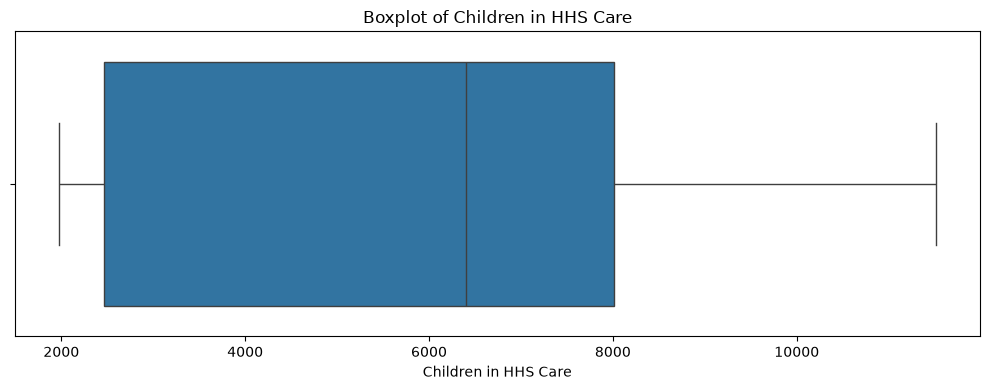

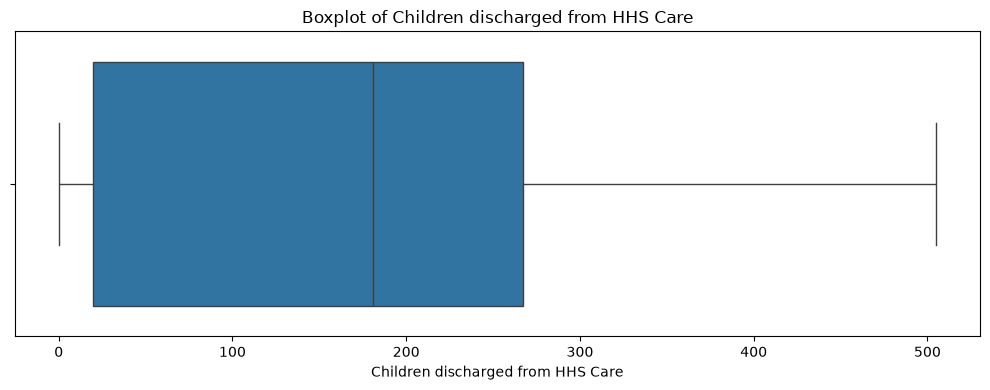

In [67]:
print("Boxplot for Outlier detection ")
for column in numeric_column:
    plt.figure(figsize=(10,4))
    sns.boxplot(x=df[column].dropna())
    plt.title(f"Boxplot of {column}")
    plt.xlabel(column)
    plt.tight_layout()
    plt.show()

In [68]:
numeric_columns=df.select_dtypes(include=np.number).columns
correaltion=df[numeric_columns].corr()
print(correaltion)

                                                 Children apprehended and placed in CBP custody*  \
Children apprehended and placed in CBP custody*                                         1.000000   
Children in CBP custody                                                                 0.950604   
Children transferred out of CBP custody                                                 0.887896   
Children in HHS Care                                                                    0.691312   
Children discharged from HHS Care                                                       0.627755   

                                                 Children in CBP custody  \
Children apprehended and placed in CBP custody*                 0.950604   
Children in CBP custody                                         1.000000   
Children transferred out of CBP custody                         0.925039   
Children in HHS Care                                            0.663662   
Children discharged

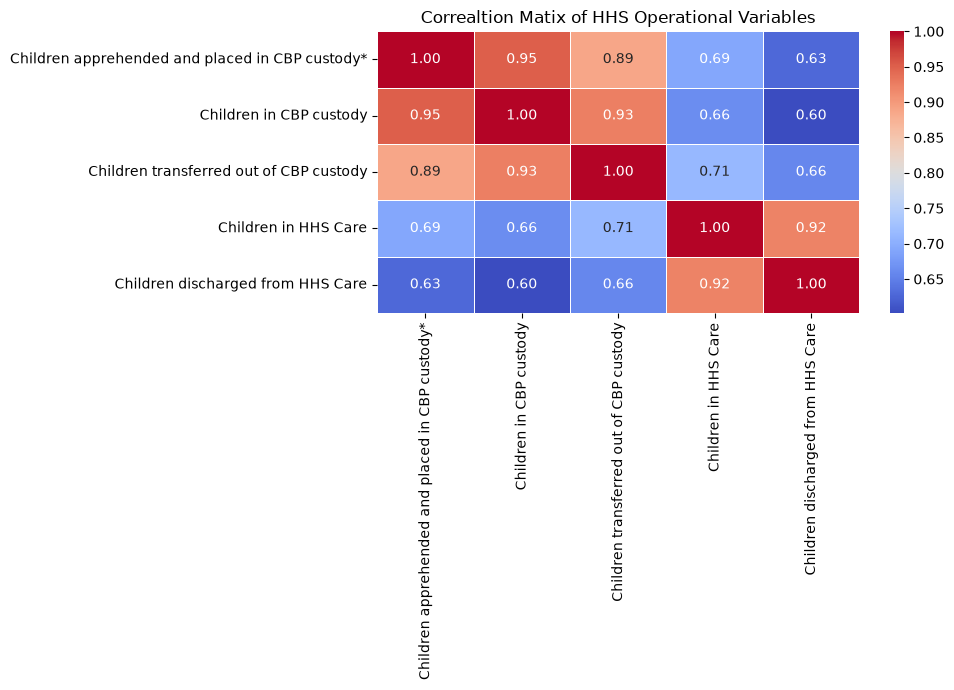

In [69]:
plt.figure(figsize=(10,7))
sns.heatmap(
    correaltion,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)
plt.title("Correaltion Matix of HHS Operational Variables")
plt.tight_layout()
plt.show()

In [70]:
df.index=pd.to_datetime(df.index)

weekly_pattern= (
    df.groupby(df.index.dayofweek)["Children in HHS Care"].mean()
)

day_names=[
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Saturday",
    "Sunday"
]
weekly_pattern.index=day_names
print(weekly_pattern)


Monday       6063.517241
Tuesday      6082.436242
Wednesday    6158.829932
Thursday     6128.789116
Saturday     4296.500000
Sunday       5875.015385
Name: Children in HHS Care, dtype: float64


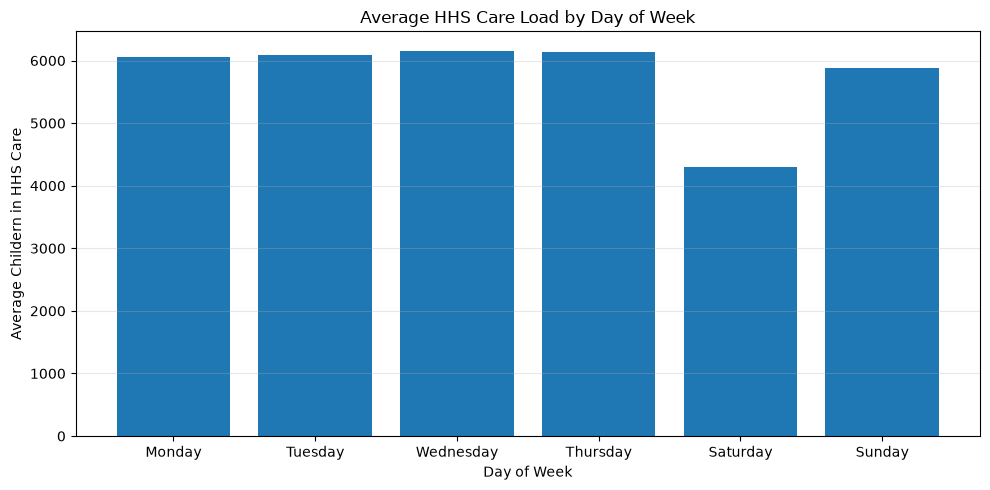

In [71]:
plt.figure(figsize=(10,5))

plt.bar(
    weekly_pattern.index,
    weekly_pattern.values
)

plt.title("Average HHS Care Load by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Childern in HHS Care")

plt.grid(axis="y",alpha=0.3)
plt.tight_layout()
plt.show()

In [72]:
df["Month"]=df.index.month

In [73]:
monthly_pattern=df.groupby("Month")[
    "Children in HHS Care"
].mean()

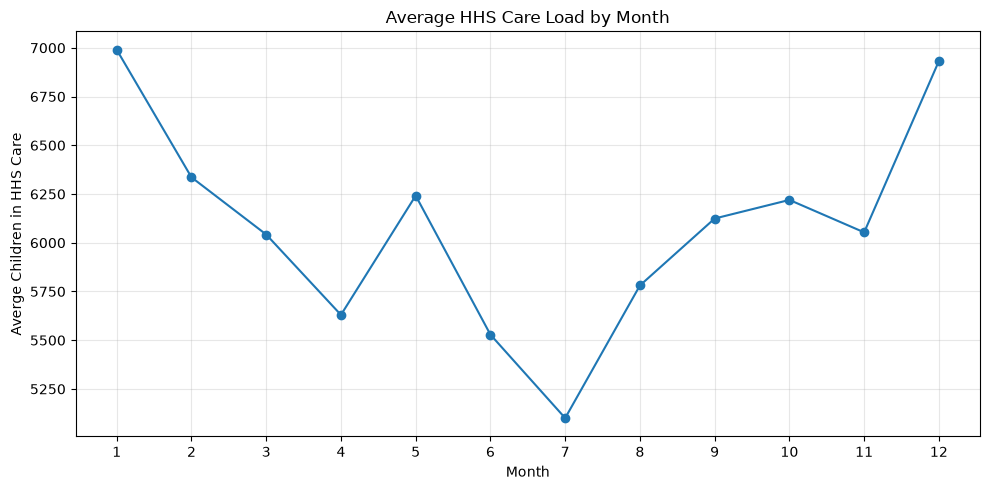

In [74]:
plt.figure(figsize=(10,5))

plt.plot(
    monthly_pattern.index,
    monthly_pattern.values,
    marker="o"
)

plt.title("Average HHS Care Load by Month")
plt.xlabel("Month")
plt.ylabel("Averge Children in HHS Care")
plt.xticks(range(1,13))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [75]:
df["HHS_7D_MA"]=(
    df["Children in HHS Care"]
    .rolling(window=7)
    .mean()
)

In [76]:
df["HHS_14D_MA"]=(
    df["Children in HHS Care"]
    .rolling(window=14)
    .mean()
)

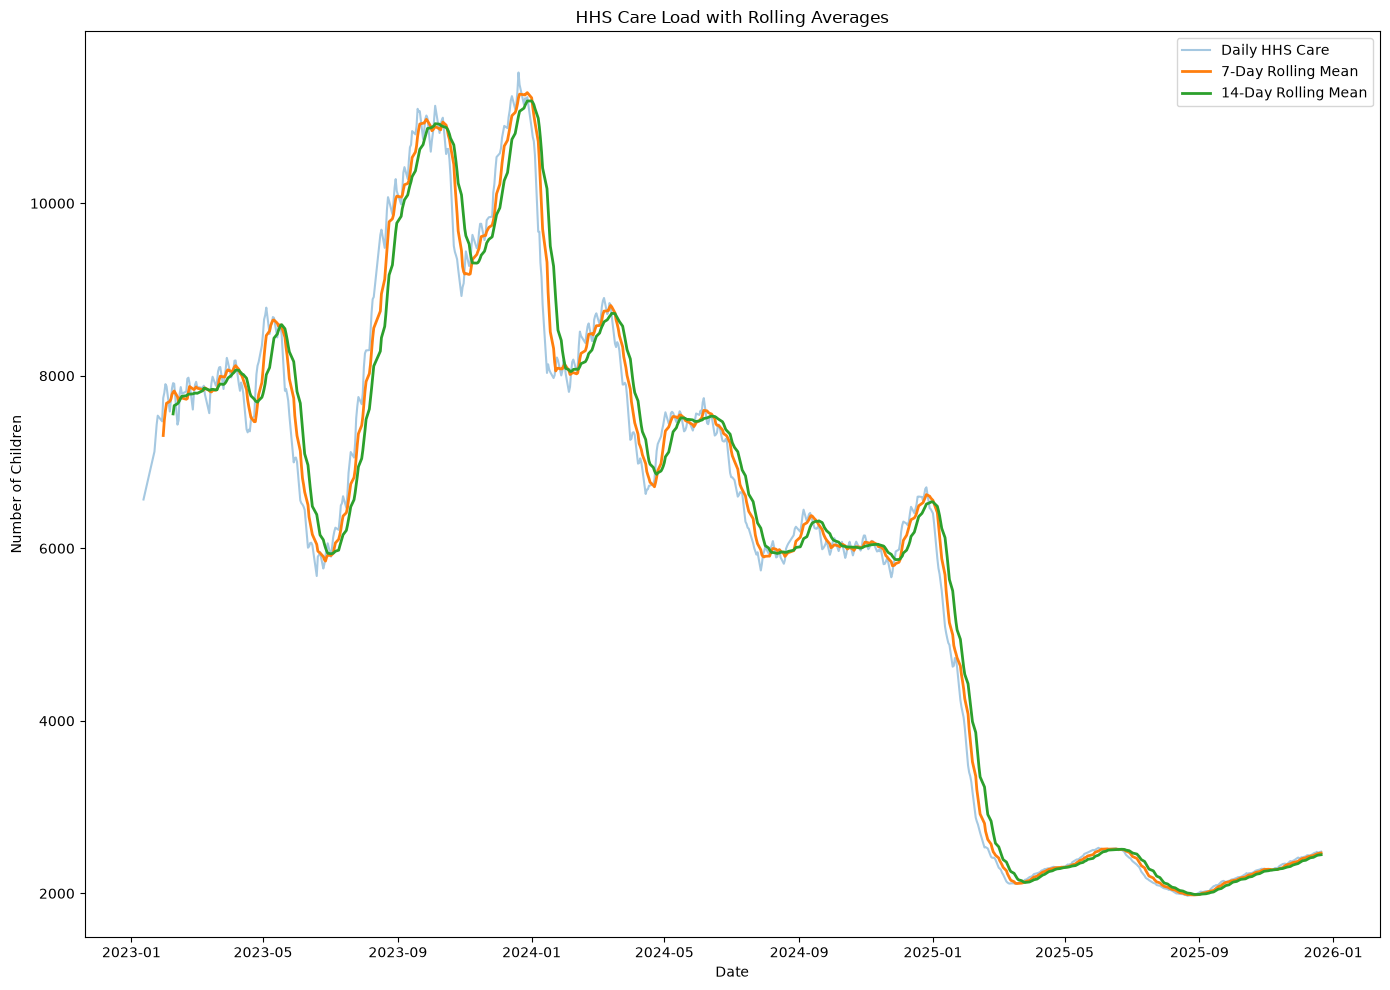

In [77]:
plt.figure(figsize=(14,10))

plt.plot(
    df.index,
    df["Children in HHS Care"],
    label="Daily HHS Care",
    alpha=0.4
)

plt.plot(
    df.index,
    df["HHS_7D_MA"],
    label="7-Day Rolling Mean",
    linewidth=2
)

plt.plot(
    df.index,
    df["HHS_14D_MA"],
    label="14-Day Rolling Mean",
    linewidth=2
)

plt.title("HHS Care Load with Rolling Averages")
plt.xlabel("Date")
plt.ylabel("Number of Children")
plt.legend()
plt.tight_layout()
plt.show()

In [78]:
df['HHS_7D_STD']=(
    df["Children in HHS Care"]
    .rolling(window=7)
    .std()
)

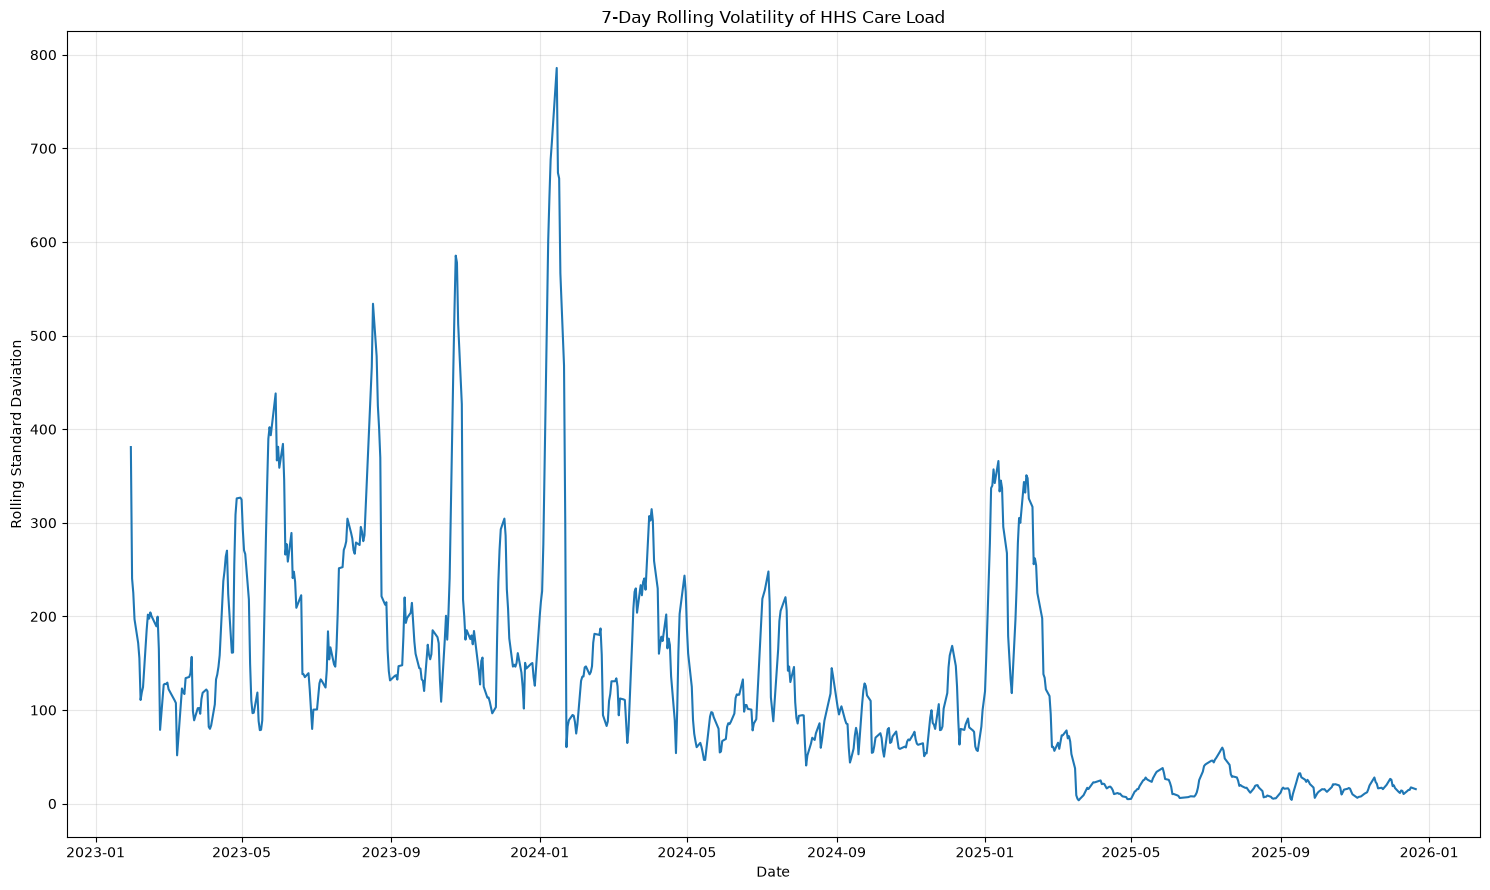

In [79]:
plt.figure(figsize=(15,9))

plt.plot(
    df.index,
    df["HHS_7D_STD"]
)

plt.title("7-Day Rolling Volatility of HHS Care Load")
plt.xlabel("Date")
plt.ylabel("Rolling Standard Daviation")

plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

In [80]:
df["Net_Pressure"]=(
    df["Children transferred out of CBP custody"] -
    df["Children discharged from HHS Care"]
)

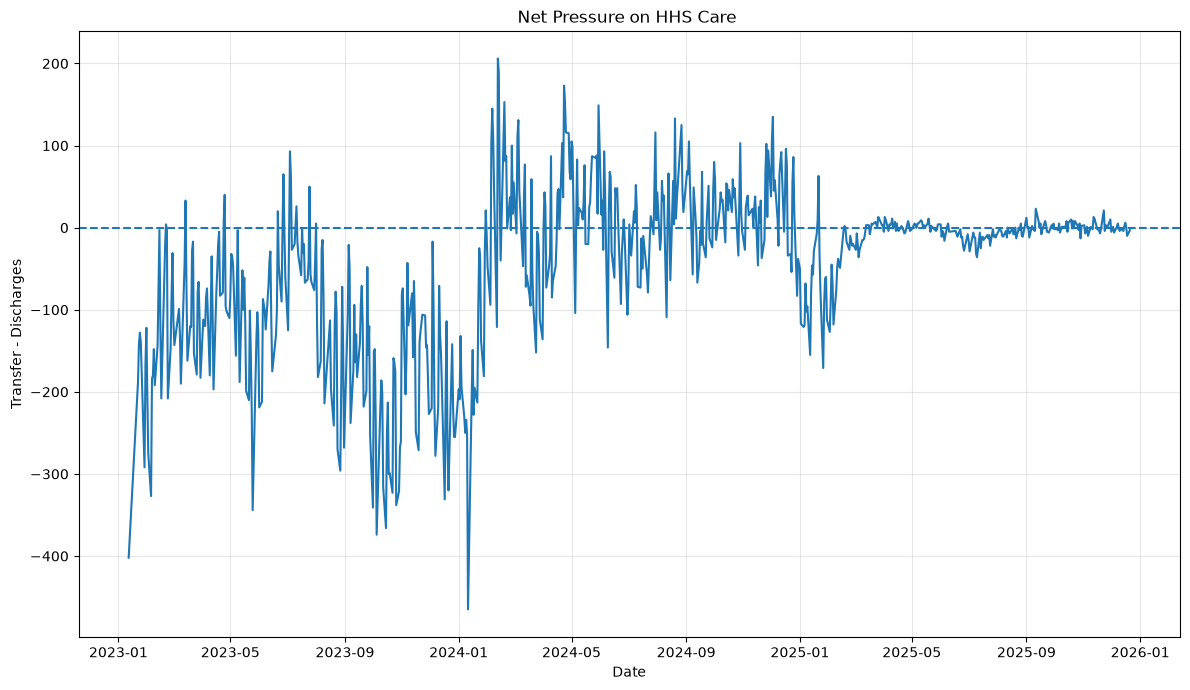

In [81]:
plt.figure(figsize=(12,7))
plt.plot(
    df.index,
    df["Net_Pressure"]
)

plt.axhline(0,linestyle="--")
plt.title("Net Pressure on HHS Care ")
plt.xlabel("Date")
plt.ylabel("Transfer - Discharges")
plt.tight_layout()
plt.grid(alpha=0.3)
plt.show()

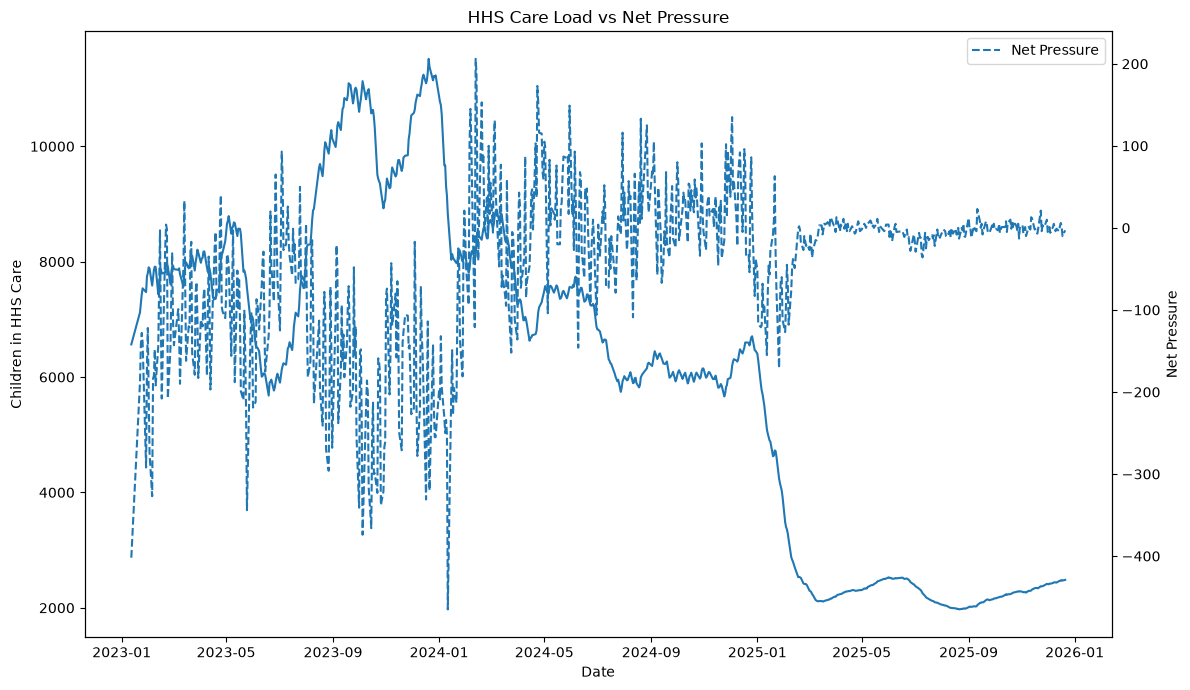

In [82]:
fig,ax1=plt.subplots(figsize=(12,7))

ax1.plot(
    df.index,
    df["Children in HHS Care"],
    label="HHS Care"
)

ax1.set_xlabel("Date")
ax1.set_ylabel("Children in HHS Care")
ax2=ax1.twinx()

ax2.plot(
    df.index,
    df["Net_Pressure"],
    linestyle='--',
    label="Net Pressure"
)
ax2.set_ylabel("Net Pressure")
plt.title("HHS Care Load vs Net Pressure")
plt.tight_layout()
plt.legend()

plt.show()

In [83]:
high_pressure=df.sort_values(
    "Net_Pressure",
    ascending=False
)[
   [
        "Children transferred out of CBP custody",
        "Children discharged from HHS Care",
        "Net_Pressure",
        "Children in HHS Care"
   ]
]
high_pressure.head(10)

,Children transferred out of CBP custody,Children discharged from HHS Care,Net_Pressure,Children in HHS Care
Date,,,,
2024-02-12,440.0,234.0,206.0,8092
2024-02-13,349.0,160.0,189.0,8348
2024-04-23,307.0,134.0,173.0,6967
2024-04-24,307.0,154.0,153.0,7128
2024-02-19,371.0,218.0,153.0,8380
2024-05-30,339.0,190.0,149.0,7563
2024-02-06,323.0,178.0,145.0,8045
2024-12-03,242.0,107.0,135.0,6192
2024-08-20,245.0,112.0,133.0,5995


In [84]:
summary=df[
    [
        "Children apprehended and placed in CBP custody*",
        "Children in CBP custody",
        "Children transferred out of CBP custody",
        "Children in HHS Care",
        "Children discharged from HHS Care",
        "Net_Pressure"
    ]
].describe().T

summary

,count,mean,std,min,25%,50%,75%,max
Children apprehended and placed in CBP custody*,720.0,93.523611,72.646625,0.0,12.00,99.0,147.25,333.0
Children in CBP custody,720.0,171.494444,126.354965,7.0,36.00,193.0,263.25,531.0
Children transferred out of CBP custody,720.0,128.668056,97.322012,0.0,14.00,157.0,199.25,440.0
Children in HHS Care,720.0,6061.275000,2833.070109,1972.0,2467.75,6406.5,8010.25,11516.0
Children discharged from HHS Care,720.0,173.406944,125.702841,0.0,19.75,181.0,267.00,505.0
Net_Pressure,720.0,-44.738889,95.863856,-465.0,-94.25,-11.5,5.25,206.0


In [85]:
print("Start date:",df.index.min())
print("End date:",df.index.max())
print("Number of observation:",len(df))

Start date: 2023-01-12 00:00:00
End date: 2025-12-21 00:00:00
Number of observation: 720


In [86]:
date_range=pd.date_range(
    start=df.index.min(),
    end=df.index.max(),
    freq="D"
)

missing_dates=date_range.difference(df.index)

print("Expected daily observation:",len(date_range))
print("Actual observation:",len(df))
print("Missing dates:",len(missing_dates))

Expected daily observation: 1075
Actual observation: 720
Missing dates: 355


In [89]:
df.to_csv(
    "data/processed/hhs_eda_dataset.csv"
)

## EDA Insights

### 1. HHS Care Load
The historical trend of children in HHS care shows [describe the observed trend].

### 2. Transfers vs Discharges
The comparison between transfers and discharges indicates [describe the observed relationship].

### 3. Distribution
The distributions of the operational variables show [normal/skewed/multimodal] patterns.

### 4. Outliers
Several extreme observations were identified. These observations were not automatically removed because they may represent genuine operational surges.

### 5. Correlation
The correlation analysis indicates [describe strongest relationships observed].

### 6. Seasonality
The weekly/monthly analysis indicates [describe any recurring patterns observed].

### 7. Rolling Trend
The rolling averages reveal [describe sustained increases/decreases].

### 8. Operational Pressure
Periods where transfers exceeded discharges created positive net pressure on the HHS care system.

### 9. Forecasting Implication
The observed trends, lagged behavior, operational flows, and potential seasonality indicate that time-series and machine-learning forecasting approaches are appropriate for predicting future HHS care load.

In [91]:
print(missing_dates[:50])

DatetimeIndex(['2023-01-13', '2023-01-14', '2023-01-15', '2023-01-16',
               '2023-01-17', '2023-01-18', '2023-01-19', '2023-01-20',
               '2023-01-21', '2023-01-26', '2023-01-27', '2023-01-28',
               '2023-02-03', '2023-02-04', '2023-02-10', '2023-02-11',
               '2023-02-17', '2023-02-18', '2023-02-19', '2023-02-24',
               '2023-02-25', '2023-03-03', '2023-03-04', '2023-03-05',
               '2023-03-06', '2023-03-10', '2023-03-11', '2023-03-12',
               '2023-03-17', '2023-03-18', '2023-03-24', '2023-03-25',
               '2023-03-31', '2023-04-01', '2023-04-07', '2023-04-08',
               '2023-04-14', '2023-04-15', '2023-04-21', '2023-04-22',
               '2023-04-28', '2023-04-29', '2023-05-05', '2023-05-06',
               '2023-05-12', '2023-05-13', '2023-05-19', '2023-05-20',
               '2023-05-26', '2023-05-27'],
              dtype='datetime64[us]', freq=None)


In [94]:
print(
    missing_dates.to_series()
    .dt.year
    .value_counts()
    .sort_index()
)

2023    124
2024    115
2025    116
Name: count, dtype: int64


In [ ]:
df = df.copy()

df["Date"] = pd.to_datetime(
    df["Date"],
    errors="coerce"
)

df = df.sort_values("Date").reset_index(drop=True)

print(df["Date"].dtype)
print(df["Date"].head())
print(df["Date"].isna().sum())

datetime64[us]
0   2023-01-12
1   2023-01-22
2   2023-01-23
3   2023-01-24
4   2023-01-25
Name: Date, dtype: datetime64[us]
450


In [99]:
df = df.sort_values("Date").copy()

date_diff = df["Date"].diff()

df["Gap_Days"] = date_diff.dt.days

In [100]:
print(
    df["Gap_Days"]
    .value_counts()
    .sort_index()
    .head(20)
)

Gap_Days
1.0     558
2.0      10
3.0     122
4.0      23
5.0       3
6.0       1
7.0       1
10.0      1
Name: count, dtype: int64


In [101]:
print(
    df[
        df["Gap_Days"] > 1
    ][
        ["Date","Gap_Days"]
    ]
    .sort_values(
        "Gap_Days",
        ascending=False
    )
    .head(20)
)

          Date  Gap_Days
1   2023-01-22      10.0
593 2025-06-17       7.0
138 2023-08-16       6.0
394 2024-08-27       5.0
29  2023-03-07       5.0
582 2025-05-27       5.0
86  2023-05-29       4.0
32  2023-03-13       4.0
5   2023-01-29       4.0
174 2023-10-09       4.0
197 2023-11-12       4.0
239 2024-01-15       4.0
445 2024-11-11       4.0
643 2025-09-01       4.0
100 2023-06-19       4.0
20  2023-02-20       4.0
397 2024-09-02       4.0
226 2023-12-25       4.0
230 2024-01-01       4.0
513 2025-02-17       4.0


In [105]:
missing_df = pd.DataFrame({
    "Date": missing_dates
})
missing_df["Day_of_Week"] = missing_df["Date"].dt.day_name()



In [106]:
missing_df["Day_of_Week"].value_counts().reindex([
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
])

Day_of_Week
Monday         8
Tuesday        4
Wednesday      6
Thursday       7
Friday       152
Saturday     154
Sunday        24
Name: count, dtype: int64

In [108]:
df["Day_of_Week"] = df["Date"].dt.day_name()
df["Day_of_Week"].value_counts().reindex([
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
])

Day_of_Week
Monday       145.0
Tuesday      149.0
Wednesday    147.0
Thursday     147.0
Friday         2.0
Saturday       NaN
Sunday       130.0
Name: count, dtype: float64

## Data Continuity and Reporting Pattern

The dataset contains 720 observations between January 12, 2023 and December 21, 2025, compared with 1,075 calendar days in the same period.

A total of 355 calendar dates have no observations. Investigation of the missing dates shows that the missingness is highly systematic rather than random.

Friday and Saturday account for the majority of missing dates, with 152 missing Fridays and 154 missing Saturdays. In contrast, only 2 Friday observations and no Saturday observations are present in the dataset.

This indicates that the source data follows a non-uniform reporting schedule rather than representing a complete daily time series.

Therefore, missing dates were not filled through interpolation. Artificially estimating the HHS care load for systematically unreported dates could introduce bias and create false operational signals.

For forecasting, calendar-aware features and date-based lag construction will be used rather than assuming that every row represents a consecutive calendar day.